## 02 — Training: Run 1 (Baseline)

**Ablation position:** Run 1 of 5 — plain ResNet50, standard cross-entropy, no augmentation, no crop.
This run exists to answer one question: how does an off-the-shelf ResNet50 do on raw GTSRB with
nothing else applied? Every later run adds exactly one ingredient on top of this baseline, so
whatever weaknesses show up here (which classes get confused, how far macro-F1 sits below accuracy)
are what Runs 2–5 are trying to fix.

Phase 1 and Phase 2 (below) both run as part of THIS SAME notebook execution — they're not
separate ablation runs, they're two training stages within Run 1 (and within every other run too).

| Run | Adds | This notebook |
|---|---|---|
| 1 | — (baseline) | ✅ this notebook |
| 2 | class-weighted loss | reuse this notebook, set `USE_CLASS_WEIGHTS = True` |
| 3 | augmentation pipeline | set `USE_AUGMENTATION = True` |
| 4 | bounding-box crop | set `USE_BBOX_CROP = True` — now just a flag, since the pipeline saves cropped/uncropped into separate subfolders |
| 5 | CBAM attention | swap in attention-augmented `build_resnet50_model` |

In [64]:
# ============================================================
# RUN CONFIG — this is the only cell that should change between
# the five ablation runs. Everything below reads from this dict.
# ============================================================
RUN_NAME = "run4_bbcrop_uncrop"

USE_CLASS_WEIGHTS = True   # Run 2 flips this to True
USE_AUGMENTATION  = True  # Run 3 flips this to True
USE_BBOX_CROP     = True   # Run 4 flips this to True — picks the "cropped" data subfolder
USE_ATTENTION     = None    # Run 5 — "cbam" once model.py has an attention-augmented builder

IMG_SIZE     = 64
NUM_CLASSES  = 43
BATCH_SIZE   = 32
RANDOM_SEED  = 42

PHASE1_EPOCHS = 5    # head-only warmup, backbone frozen
PHASE2_EPOCHS = 15   # full fine-tune, early stopping will usually cut this short

import os
import sys
from pathlib import Path
from google.colab import drive

# drive.mount('/content/drive', force_remount=True)

# if os.path.exists('/content/drive'):
#     %ls
# else:
#     print("Drive not connected ! ")
    
# os.chdir('/content')

## Environment setup

CODE_ROOT and DATA_DIR are kept separate on purpose:
- CODE_ROOT is where src/model.py lives. On Colab that's a freshly git-cloned
  repo under ephemeral /content — fine to lose on disconnect, re-cloning takes
  seconds. Locally it's just your existing checkout.
- DATA_DIR is where processed/ and checkpoints/ live. On Colab that MUST be
  under /content/drive/... (persistent) — anything saved only to /content
  disappears the moment the runtime disconnects or recycles. Locally it's the
  same folder as CODE_ROOT, since there's no separate persistence layer to
  worry about.

In [65]:
COLAB_DIR = Path("/content")
PROJECT_ROOT = Path("/content/drive/MyDrive/Group_E/Final_Project/03-Code/")
DATA_DIR = COLAB_DIR / "drive" / "MyDrive"
UNCROPPED_PROCESSED_DIR = DATA_DIR / "processed" / "uncropped"
CROPPED_PROCESSED_DIR = DATA_DIR / "processed" / "cropped"
TEST_CLASS_DIR = DATA_DIR / "processed"

os.chdir(PROJECT_ROOT)

import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import wandb
import src.model as gtsrb_model  # src/model.py

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("TF:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TF: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [66]:
import os
from dotenv import load_dotenv
import wandb

load_dotenv(os.path.join(PROJECT_ROOT, ".env"))
wandb.login(key=os.getenv("WANDB_API_KEY"))
print("W&B login OK")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


W&B login OK


In [67]:
X_train = np.load(os.path.join(CROPPED_PROCESSED_DIR, "X_train.npy"))
y_train = np.load(os.path.join(CROPPED_PROCESSED_DIR, "y_train.npy"))
X_val   = np.load(os.path.join(CROPPED_PROCESSED_DIR, "X_val.npy"))
y_val   = np.load(os.path.join(CROPPED_PROCESSED_DIR, "y_val.npy"))
X_test = np.load(os.path.join(TEST_CLASS_DIR, "X_test.npy"))
Y_test = np.load(os.path.join(TEST_CLASS_DIR, "y_test.npy"))

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("X_val:  ", X_val.shape, X_val.dtype)
print("y_val:  ", y_val.shape, y_val.dtype)

# --- sanity check: value range assumption used in model.py ---
print(f"X_train range: [{X_train.min():.4f}, {X_train.max():.4f}]")
assert 0.0 <= X_train.min() and X_train.max() <= 1.0 + 1e-5, (
    "X_train is not in [0, 1] — model.py's Rescaling(255.0) step assumes it is. "
    "Fix the data pipeline output or adjust build_resnet50_model() before training."
)
assert X_train.shape[1:] == (IMG_SIZE, IMG_SIZE, 3)
assert set(np.unique(y_train)) <= set(range(NUM_CLASSES))
print("Sanity checks passed.")

X_train: (31349, 64, 64, 3) float32
y_train: (31349,) int32
X_val:   (7860, 64, 64, 3) float32
y_val:   (7860,) int32
X_train range: [0.0000, 1.0000]
Sanity checks passed.


In [68]:
if USE_CLASS_WEIGHTS:
    class_weights = np.load(os.path.join(TEST_CLASS_DIR, "class_weights.npy"))
    class_weight_dict = dict(enumerate(class_weights))
else:
    class_weight_dict = None

print("class_weight_dict:", "None (Run 1 baseline)" if class_weight_dict is None else "loaded")

class_weight_dict: loaded


In [69]:
def make_dataset(X, y, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=RANDOM_SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val, y_val, shuffle=False)

if USE_AUGMENTATION:
    from src.augmentation import build_augmentation_pipeline  # src/augmentation.py
    augmentation_pipeline = build_augmentation_pipeline()
    print("Augmentation pipeline built — will be attached inside the model graph.")


Augmentation pipeline built — will be attached inside the model graph.


In [70]:
wandb.init(
    project="gtsrb-traffic-sign-recognition",
    name=RUN_NAME,
    config={
        "backbone": "ResNet50",
        "pretrained": "imagenet",
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "use_class_weights": USE_CLASS_WEIGHTS,
        "use_augmentation": USE_AUGMENTATION,
        "use_bbox_crop": USE_BBOX_CROP,
        "attention": USE_ATTENTION,
        "phase1_epochs": PHASE1_EPOCHS,
        "phase2_epochs": PHASE2_EPOCHS,
        "seed": RANDOM_SEED,
    },
)

In [71]:
model, base_model = gtsrb_model.build_resnet50_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    freeze_base=True,
    weights="imagenet",
)
gtsrb_model.compile_model(model, learning_rate=1e-3)
model.summary()

Model: "resnet50_gtsrb"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 64, 64, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ to_0_255            │ (None, 64, 64, 3) │          0 │ image[0][0]       │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_12         │ (None, 64, 64)    │          0 │ to_0_255[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_13         │ (None, 64, 64)    │          0 │ to_0_255[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_14         │ (None, 64, 64)    │          0 │ to_0_255[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_4 (Stack)     │ (None, 64, 64, 3) │          0 │ get_item_12[0][0… │
│                     │                   │            │ get_item_13[0][0… │
│                     │                   │            │ get_item_14[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 64, 3) │          0 │ stack_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2, 2,      │ 23,587,712 │ add_4[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout        │ (None, 2048)      │          0 │ gap[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 43)        │     88,107 │ head_dropout[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,675,819 (90.32 MB)

 Trainable params: 88,107 (344.17 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [72]:
checkpoint_path = os.path.join(PROJECT_ROOT, "checkpoints", f"{RUN_NAME}.keras")
print(checkpoint_path)
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

if os.path.exists(checkpoint_path):
    print(f"Found existing checkpoint at {checkpoint_path} — resuming from it.")
    model = keras.models.load_model(checkpoint_path)
    # base_model is now whatever layer inside `model` was the backbone —
    # re-fetch it by name rather than relying on the old base_model reference
    base_model = model.get_layer("resnet50")
    base_model.trainable = True
    gtsrb_model.compile_model(model, learning_rate=1e-5)
else:
    print("No checkpoint found — starting fresh.")
    # ... your normal build_resnet50_model + Phase 1 flow

callbacks = gtsrb_model.get_callbacks(checkpoint_path, patience=5, use_wandb=True)

/content/drive/MyDrive/Group_E/Final_Project/03-Code/checkpoints/run4_bbcrop_uncrop.keras
No checkpoint found — starting fresh.


In [73]:
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)

Epoch 1/5
980/980 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.6069 - loss: 1.4517 - val_accuracy: 0.5981 - val_loss: 1.6723 - learning_rate: 0.0010
Epoch 2/5
980/980 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7803 - loss: 0.5681 - val_accuracy: 0.6142 - val_loss: 1.7987 - learning_rate: 0.0010
Epoch 3/5
980/980 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8183 - loss: 0.4515 - val_accuracy: 0.6379 - val_loss: 1.6966 - learning_rate: 0.0010
Epoch 4/5
980/980 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8399 - loss: 0.3812 - val_accuracy: 0.6443 - val_loss: 1.7823 - learning_rate: 0.0010
Epoch 5/5
980/980 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8746 - loss: 0.2612 - val_accuracy: 0.6618 - val_loss: 1.5888 - learning_rate: 5.0000e-04


In [74]:
gtsrb_model.unfreeze_for_finetune(model, base_model, learning_rate=1e-5)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)

Epoch 1/15
980/980 ━━━━━━━━━━━━━━━━━━━━ 135s 72ms/step - accuracy: 0.5757 - loss: 1.9834 - val_accuracy: 0.6503 - val_loss: 1.4920 - learning_rate: 1.0000e-05
Epoch 2/15
980/980 ━━━━━━━━━━━━━━━━━━━━ 32s 33ms/step - accuracy: 0.8091 - loss: 0.4533 - val_accuracy: 0.7637 - val_loss: 0.9424 - learning_rate: 1.0000e-05
Epoch 3/15
980/980 ━━━━━━━━━━━━━━━━━━━━ 32s 33ms/step - accuracy: 0.8943 - loss: 0.2048 - val_accuracy: 0.8226 - val_loss: 0.6673 - learning_rate: 1.0000e-05
Epoch 4/15
980/980 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - accuracy: 0.9372 - loss: 0.1127 - val_accuracy: 0.8632 - val_loss: 0.5113 - learning_rate: 1.0000e-05
Epoch 5/15
980/980 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - accuracy: 0.9651 - loss: 0.0645 - val_accuracy: 0.8854 - val_loss: 0.4193 - learning_rate: 1.0000e-05
Epoch 6/15
980/980 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.9778 - loss: 0.0410 - val_accuracy: 0.9003 - val_loss: 0.3882 - learning_rate: 1.0000e-05
Epoch 7/15
980/980 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/st

In [75]:
y_pred_probs = model.predict(val_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

macro_f1 = f1_score(y_val, y_pred, average="macro")
weighted_f1 = f1_score(y_val, y_pred, average="weighted")
print(f"Macro F1:    {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

report = classification_report(y_val, y_pred, digits=3)
print(report)

wandb.log({"val_macro_f1": macro_f1, "val_weighted_f1": weighted_f1})

Macro F1:    0.9278
Weighted F1: 0.9526
              precision    recall  f1-score   support

           0      1.000     0.967     0.983        60
           1      0.961     0.940     0.951       450
           2      0.902     0.938     0.919       450
           3      0.919     0.988     0.952       240
           4      0.945     0.991     0.967       450
           5      0.949     0.862     0.903       390
           6      0.984     1.000     0.992        60
           7      0.971     0.989     0.980       270
           8      0.955     0.917     0.935       300
           9      0.990     0.987     0.988       300
          10      0.990     0.990     0.990       420
          11      0.978     0.857     0.914       210
          12      0.996     0.980     0.988       510
          13      0.970     0.997     0.984       390
          14      1.000     0.994     0.997       180
          15      0.989     0.967     0.978        90
          16      0.992     0.992     0.9

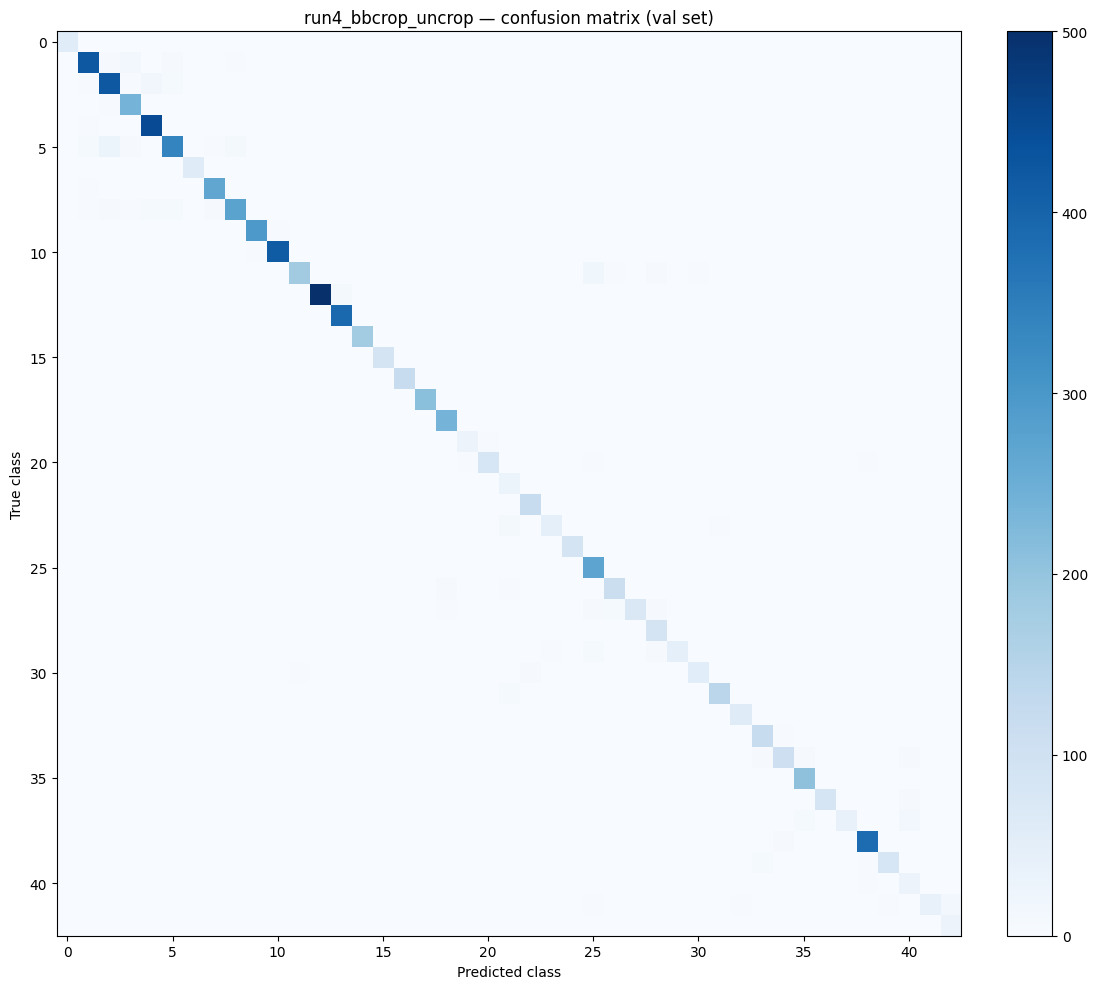

In [76]:
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title(f"{RUN_NAME} — confusion matrix (val set)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

fig_path = os.path.join(PROJECT_ROOT, "checkpoints", f"{RUN_NAME}_confusion_matrix.png")
plt.savefig(fig_path, dpi=150)
plt.show()

wandb.log({"confusion_matrix": wandb.Image(fig_path)})

In [77]:
model_path = os.path.join(PROJECT_ROOT, "checkpoints", f"{RUN_NAME}_final.keras")
model.save(model_path)

artifact = wandb.Artifact(RUN_NAME, type="model")
artifact.add_file(model_path)
wandb.log_artifact(artifact)

wandb.finish()
print("Saved:", model_path)

epoch/accuracy,▂▄▅▅▆▁▅▆▇▇██████████
epoch/epoch,▁▁▂▃▃▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/learning_rate,███▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,▆▃▃▂▂█▃▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▁▂▂▂▂▄▅▆▇▇▇▇▇██████
epoch/val_loss,▇███▇▇▄▃▂▂▂▂▂▂▁▁▁▁▁▁
val_macro_f1,▁
val_weighted_f1,▁
epoch/accuracy,0.9986
epoch/epoch,14
epoch/learning_rate,0.0


Saved: /content/drive/MyDrive/Group_E/Final_Project/03-Code/checkpoints/run4_bbcrop_uncrop_final.keras


In [87]:
test_ds = make_dataset(X_test, Y_test, shuffle=False)

# # If your Colab session is fresh, reload Run 4's checkpoint first:
check = Path("/content/drive/MyDrive/Group_E/Final_Project/03-Code/checkpoints/run3_augmentation_uncrop_final.keras")
model = keras.models.load_model(check)

y_test_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)

test_accuracy = (y_test_pred == Y_test).mean()
test_macro_f1 = f1_score(Y_test, y_test_pred, average="macro")
test_weighted_f1 = f1_score(Y_test, y_test_pred, average="weighted")

print(f"Test accuracy:    {test_accuracy:.4f}")
print(f"Test macro F1:    {test_macro_f1:.4f}")
print(f"Test weighted F1: {test_weighted_f1:.4f}")
print(classification_report(Y_test, y_test_pred, digits=3))

Test accuracy:    0.9108
Test macro F1:    0.8756
Test weighted F1: 0.9112
              precision    recall  f1-score   support

           0      0.860     0.717     0.782        60
           1      0.903     0.865     0.884       720
           2      0.775     0.885     0.826       750
           3      0.839     0.847     0.843       450
           4      0.974     0.918     0.945       660
           5      0.842     0.814     0.828       630
           6      0.956     0.873     0.913       150
           7      0.965     0.918     0.941       450
           8      0.853     0.900     0.876       450
           9      0.985     0.985     0.985       480
          10      0.979     0.994     0.986       660
          11      0.941     0.914     0.928       420
          12      0.996     0.986     0.991       690
          13      0.980     0.996     0.988       720
          14      0.928     0.996     0.961       270
          15      1.000     0.995     0.998       210
      

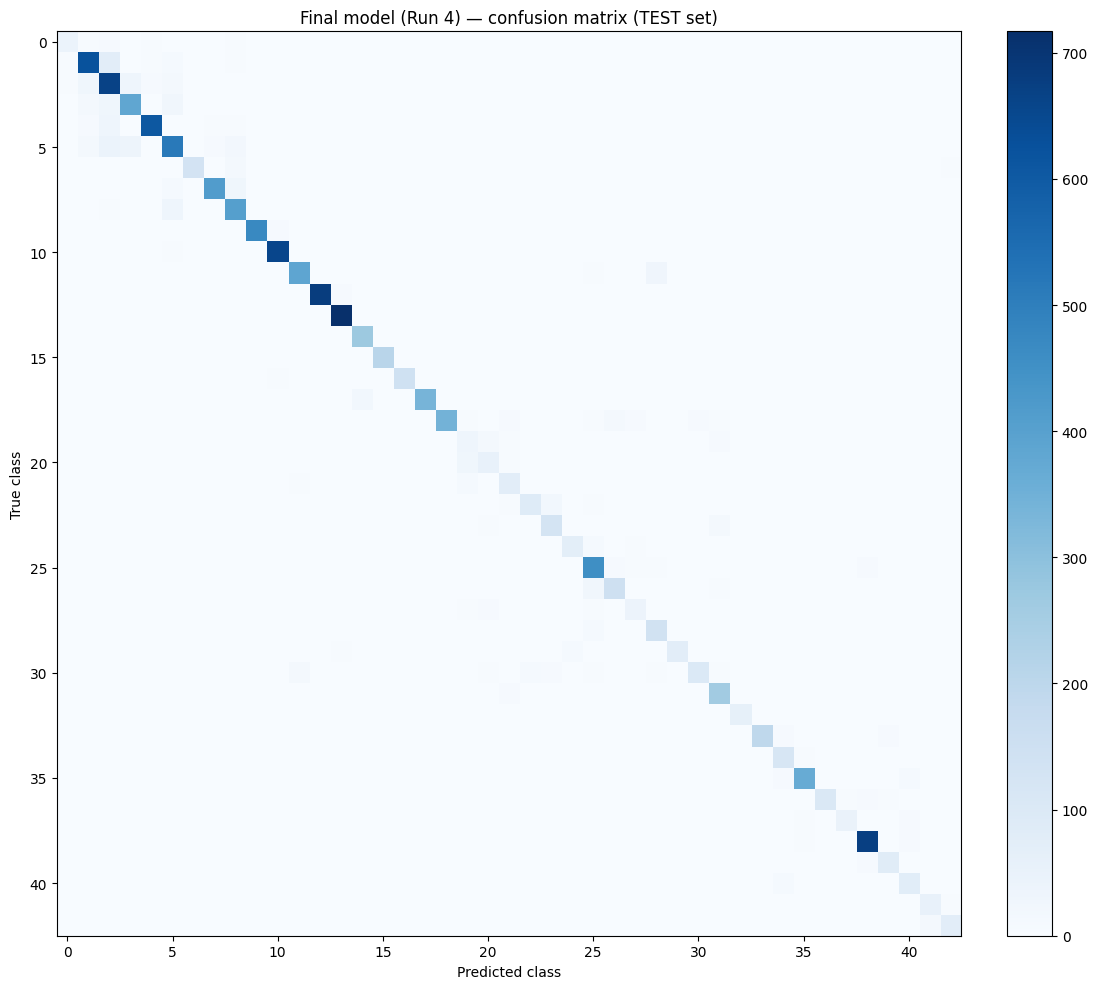

In [85]:
cm_test = confusion_matrix(Y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_test, cmap="Blues")
ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")
ax.set_title("Final model (Run 4) — confusion matrix (TEST set)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()